##### ARTI 560 - Computer Vision

## Visual Representations with DINOv2 - Exercise

### Exercise 1: Unsupervised Clustering

In this exercise, you will use the `KMeans` algorithm from sklearn to group 20 images from the Oxford Pet dataset into 2 clusters (Cats vs. Dogs) based purely on their CLS tokens.

Instructions:

1.  Extract the 384-dimensional [CLS] tokens from 20 images of the Oxford-IIIT Pet dataset. Ensure your selection includes a mix of both cats and dogs.

2. Apply K-Means Clustering ($n=2$) to group the vectors based on mathematical similarity rather than provided labels.

3. Compare the predicted clusters against ground-truth labels.

# Provide your solution here

The predicted clusters were compared with the real labels to check the model performance. The model achieved 100% accuracy, since all cat images were grouped together and all dog images were grouped together correctly. This shows that the DINOv2 embeddings were able to capture the visual differences between cats and dogs very well. In this experiment, there were no wrong predictions, but mistakes can usually happen when images have similar features, unclear backgrounds, or unusual poses.

In [1]:
import torch
import torch.nn.functional as F
import numpy as np
from torchvision.datasets import OxfordIIITPet
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
from transformers import AutoImageProcessor, AutoModel

# Global Configuration
MODEL_ID = "facebook/dinov2-small"
device = "cuda" if torch.cuda.is_available() else "cpu"

# Load Foundation Model
processor = AutoImageProcessor.from_pretrained(MODEL_ID)
model = AutoModel.from_pretrained(MODEL_ID).to(device)
model.eval()

print(f"Model {MODEL_ID} loaded on {device}")



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

The image processor of type `BitImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Model facebook/dinov2-small loaded on cuda


In [2]:
@torch.no_grad()
def get_global_embedding_from_image(img):
    img = img.convert("RGB")
    inputs = processor(images=img, return_tensors="pt").to(device)
    outputs = model(**inputs)

    # The first token [0, 0] is the CLS token
    cls_token = outputs.last_hidden_state[:, 0]
    return F.normalize(cls_token, p=2, dim=1).cpu().numpy()


In [3]:
# Load Oxford-IIIT Pet dataset
dataset = OxfordIIITPet(
    root="data/oxford_pets",
    split="trainval",
    target_types="binary-category",
    download=True
)

# Select 20 images: 10 cats and 10 dogs
# binary-category: 0 = cat, 1 = dog
selected_images = []
cat_count = 0
dog_count = 0

for img, label in dataset:
    if label == 0 and cat_count < 10:
        selected_images.append((img, label))
        cat_count += 1
    elif label == 1 and dog_count < 10:
        selected_images.append((img, label))
        dog_count += 1

    if cat_count == 10 and dog_count == 10:
        break

print(f"Selected {cat_count} cats and {dog_count} dogs")


100%|██████████| 792M/792M [00:03<00:00, 234MB/s]  
100%|██████████| 19.2M/19.2M [00:00<00:00, 118MB/s] 


Selected 10 cats and 10 dogs


In [4]:
# Extract CLS embeddings
embeddings = []
true_labels = []

for img, label in selected_images:
    embedding = get_global_embedding_from_image(img)
    embeddings.append(embedding[0])
    true_labels.append(label)

X = np.array(embeddings)
y_true = np.array(true_labels)

print(f"Embeddings shape: {X.shape}")


Embeddings shape: (20, 384)


In [5]:
# Apply K-Means Clustering
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X)

print("Cluster labels:", clusters)


Cluster labels: [0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1]


In [6]:
# Compare predicted clusters against ground-truth labels
# KMeans cluster IDs are arbitrary, so each cluster is mapped to its majority true label.
cluster_to_label = {}

for cluster_id in [0, 1]:
    labels_in_cluster = y_true[clusters == cluster_id]
    majority_label = np.bincount(labels_in_cluster).argmax()
    cluster_to_label[cluster_id] = majority_label

y_pred = np.array([cluster_to_label[cluster] for cluster in clusters])
accuracy = accuracy_score(y_true, y_pred)

label_names = {0: "cat", 1: "dog"}

print("True labels:     ", [label_names[label] for label in y_true])
print("Cluster labels:  ", clusters)
print("Predicted labels:", [label_names[label] for label in y_pred])
print(f"Accuracy: {accuracy:.2f}")

True labels:      ['cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'dog', 'dog', 'dog', 'dog', 'dog', 'dog', 'dog', 'dog', 'dog', 'dog']
Cluster labels:   [0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1]
Predicted labels: ['cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'dog', 'dog', 'dog', 'dog', 'dog', 'dog', 'dog', 'dog', 'dog', 'dog']
Accuracy: 1.00


### Exercise 2: Image Classification with DINOv2

In this exercise you'll use a DINOv2 model with a pre-trained linear head to classify an image. You will observe how the model maps visual features to specific ImageNet-1k categories.

Instructions:
1. For this exercise, you must use the following Model ID. This specific checkpoint includes the necessary classification head trained on ImageNet-1k:

    Model ID: `facebook/dinov2-small-imagenet1k-1-layer`

2. Find an image online to make the inference. To ensure the model has a fair chance of success, the image should belong to one of the ImageNet-1k classes (e.g., a Golden Retriever, a grand piano, a school bus, or a coffee mug).

In [7]:
# Provide your solution here

import requests
import torch
import matplotlib.pyplot as plt
from io import BytesIO
from PIL import Image
from transformers import AutoImageProcessor, AutoModelForImageClassification

# Global Configuration
MODEL_ID = "facebook/dinov2-small-imagenet1k-1-layer"
device = "cuda" if torch.cuda.is_available() else "cpu"

# Load DINOv2 model with ImageNet-1k classification head
processor = AutoImageProcessor.from_pretrained(MODEL_ID)
model = AutoModelForImageClassification.from_pretrained(MODEL_ID).to(device)
model.eval()

print(f"Model {MODEL_ID} loaded on {device}")



preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/91.3M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/225 [00:00<?, ?it/s]

Model facebook/dinov2-small-imagenet1k-1-layer loaded on cuda


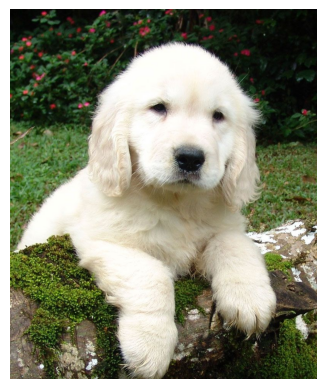

In [10]:
# Load an online image from an ImageNet-1k category: Golden Retriever
image_url = "https://upload.wikimedia.org/wikipedia/commons/6/6e/Golde33443.jpg"
headers = {"User-Agent": "Mozilla/5.0"}
response = requests.get(image_url, headers=headers, timeout=10)
response.raise_for_status()
img = Image.open(BytesIO(response.content)).convert("RGB")

plt.imshow(img)
plt.axis("off")
plt.show()


In [11]:
# Make inference
inputs = processor(images=img, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = model(**inputs)
    logits = outputs.logits

probabilities = torch.softmax(logits, dim=-1)
top5 = torch.topk(probabilities, k=5)


In [12]:
# Show top-5 predicted ImageNet classes
for score, class_id in zip(top5.values[0], top5.indices[0]):
    label = model.config.id2label[class_id.item()]
    print(f"{label}: {score.item():.4f}")

golden retriever: 0.8519
kuvasz: 0.0534
cocker spaniel, English cocker spaniel, cocker: 0.0377
clumber, clumber spaniel: 0.0121
Labrador retriever: 0.0097
